# Fuel Consumption Prediction vs. Onboard OBD Estimate

**Goal:** predict real (sensor-measured) fuel consumption from vehicle telemetry, and show whether an ML model beats the vehicle's own MAF-based fuel estimate.

- **Target:** `REAL_FUEL_USAGE_ML_MIN` (measured — ground truth)
- **Baseline:** `FUEL_USAGE_ML_MIN` (onboard MAF-based estimate — explainable, no model needed)
- **Excluded:** `PREDICTED_FUEL_USAGE`, `FUEL_USAGE_DIFF` (unknown provenance in the source dataset — not used as feature or baseline, since neither can be explained/defended)

Expects a CSV with the same columns as the OPEL dataset (`dataset.csv`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Load data

In [2]:
df = pd.read_csv("dataset.csv")

TARGET = "REAL_FUEL_USAGE_ML_MIN"     # sensor-measured ground truth
BASELINE = "FUEL_USAGE_ML_MIN"        # onboard MAF-based estimate (what we're trying to beat)
GROUP_COL = "segment_id"              # each segment = one continuous drive

df["timestamp"] = pd.to_datetime(df["timestamp"])
df['GEAR'] = df['GEAR'].fillna(0).copy()
df['GEAR'] = df['GEAR'].astype(int)

df.head()

,timestamp,RPM,SPEED,THROTTLE_POS,MAF,ACCELERATOR_POS_D,SHORT_FUEL_TRIM_1,COOLANT_TEMP,INTAKE_TEMP,LONG_FUEL_TRIM_1,...,PREDICTED_FUEL_USAGE,FUEL_USAGE_DIFF,segment_id,segment_file,RELATIVE_THROTTLE_POS,ABSOLUTE_LOAD,INTAKE_PRESSURE,REAL_FUEL_USAGE_ML_MIN,REAL_FUEL_USED_TOTAL_ML,OBD_STATUS
0,2025-04-30 13:15:12.933749,685.00,0.0,21.176471,2.04,19.607843,0.0000,NaN,NaN,NaN,...,11.273097,0.093097,1,1_01,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-30 13:15:14.083990,692.25,0.0,21.176471,2.03,19.607843,0.0000,NaN,NaN,NaN,...,11.126006,0.006006,1,1_01,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-30 13:15:15.219931,695.75,0.0,21.176471,1.96,19.607843,-1.5625,NaN,NaN,NaN,...,10.814744,0.074744,1,1_01,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-30 13:15:16.387503,683.75,0.0,21.176471,1.95,19.607843,-1.5625,NaN,NaN,NaN,...,10.814744,0.134744,1,1_01,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-30 13:15:17.538797,684.50,0.0,21.176471,1.96,19.607843,-1.5625,NaN,NaN,NaN,...,10.814744,0.074744,1,1_01,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Drop rows with no ground truth

In [3]:
before = len(df)
df = df.dropna(subset=[TARGET]).copy()
print(f"Dropped {before - len(df)} rows with no ground-truth fuel usage.")
print(f"Remaining rows: {len(df)}")

Dropped 232308 rows with no ground-truth fuel usage.
Remaining rows: 557065


## 3. Baseline performance

In [4]:
baseline_df = df.dropna(subset=[BASELINE])
baseline_mae = mean_absolute_error(baseline_df[TARGET], baseline_df[BASELINE])
baseline_rmse = np.sqrt(mean_squared_error(baseline_df[TARGET], baseline_df[BASELINE]))
baseline_r2 = r2_score(baseline_df[TARGET], baseline_df[BASELINE])

print("=" * 55)
print("BASELINE — Onboard MAF-based fuel estimate")
print("=" * 55)
print(f"Rows used : {len(baseline_df)}")
print(f"MAE       : {baseline_mae:.3f} ml/min")
print(f"RMSE      : {baseline_rmse:.3f} ml/min")
print(f"R2        : {baseline_r2:.3f}")

BASELINE — Onboard MAF-based fuel estimate
Rows used : 557065
MAE       : 5.675 ml/min
RMSE      : 6.812 ml/min
R2        : 0.957


## 4. Feature engineering

In [5]:
df = df.sort_values([GROUP_COL, "timestamp"])

roll_cols = ["RPM", "THROTTLE_POS", "MAF", "ENGINE_LOAD"]
for col in roll_cols:
    df[f"{col}_roll5"] = (
        df.groupby(GROUP_COL)[col]
        .transform(lambda s: s.rolling(5, min_periods=1).mean())
    )
    df[f"{col}_delta"] = df.groupby(GROUP_COL)[col].diff().fillna(0)

# accelerator pedal vs. actual throttle response — a gap here often signals
# throttle-by-wire smoothing / load conditions that raw values alone miss
df["THROTTLE_ACCEL_GAP"] = df["ACCELERATOR_POS_D"] - df["THROTTLE_POS"]

FEATURES = [
    "RPM", "SPEED", "THROTTLE_POS", "MAF", "ACCELERATOR_POS_D",
    "ENGINE_LOAD", "COOLANT_TEMP", "INTAKE_TEMP", "GEAR",
    "ABSOLUTE_LOAD", "INTAKE_PRESSURE",
    "RPM_roll5", "THROTTLE_POS_roll5", "MAF_roll5", "ENGINE_LOAD_roll5",
    "RPM_delta", "THROTTLE_POS_delta", "MAF_delta", "ENGINE_LOAD_delta",
    "THROTTLE_ACCEL_GAP",
]
FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES].copy()
y = df[TARGET].copy()
groups = df[GROUP_COL]

X = X.fillna(X.median(numeric_only=True))
X.shape

(557065, 20)

## 5. Train/test split BY SEGMENT

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train segments: {groups.iloc[train_idx].nunique()} | "
      f"Test segments: {groups.iloc[test_idx].nunique()}")
print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")

Train segments: 12 | Test segments: 4
Train rows: 432023 | Test rows: 125042


## 6. Train models

In [7]:
linear_model = LinearRegression()
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

## 7. Evaluate — train AND test

In [8]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2  : {r2:.3f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}

results = {}
for name, model in [("Linear Regression", linear_model), ("Random Forest", rf_model)]:
    print("\n" + "=" * 55)
    print(f"{name} — TRAIN")
    print("=" * 55)
    results[f"{name}_train"] = evaluate(y_train, model.predict(X_train))

    print("\n" + "=" * 55)
    print(f"{name} — TEST")
    print("=" * 55)
    results[f"{name}_test"] = evaluate(y_test, model.predict(X_test))

rf_test_pred = rf_model.predict(X_test)
linear_test_pred = linear_model.predict(X_test)


Linear Regression — TRAIN
MAE : 2.405
RMSE: 3.617
R2  : 0.988

Linear Regression — TEST
MAE : 2.430
RMSE: 4.316
R2  : 0.984

Random Forest — TRAIN
MAE : 1.597
RMSE: 2.293
R2  : 0.995

Random Forest — TEST
MAE : 1.772
RMSE: 3.543
R2  : 0.989


## 8. Model vs. baseline

In [9]:
print("=" * 55)
print("MODEL vs BASELINE (test set, MAE — lower is better)")
print("=" * 55)
print(f"Onboard MAF estimate : {baseline_mae:.3f} ml/min")
print(f"Linear Regression    : {results['Linear Regression_test']['mae']:.3f} ml/min")
print(f"Random Forest        : {results['Random Forest_test']['mae']:.3f} ml/min")

improvement = (baseline_mae - results["Random Forest_test"]["mae"]) / baseline_mae * 100
print(f"\nRandom Forest improves on the onboard estimate by {improvement:.1f}% (MAE)")

MODEL vs BASELINE (test set, MAE — lower is better)
Onboard MAF estimate : 5.675 ml/min
Linear Regression    : 2.430 ml/min
Random Forest        : 1.772 ml/min

Random Forest improves on the onboard estimate by 68.8% (MAE)


## 9. MAF ablation

How much do the other sensors add beyond MAF alone? The baseline formula is itself MAF-derived, so if the model is also ~100% MAF-driven, "beats the baseline" is a narrower claim than "multi-sensor fusion" — worth knowing before writing the README.

In [10]:
maf_related = [f for f in FEATURES if f.startswith("MAF")]
FEATURES_NO_MAF = [f for f in FEATURES if f not in maf_related]

rf_no_maf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf_no_maf.fit(X_train[FEATURES_NO_MAF], y_train)
no_maf_pred = rf_no_maf.predict(X_test[FEATURES_NO_MAF])
no_maf_mae = mean_absolute_error(y_test, no_maf_pred)
no_maf_r2 = r2_score(y_test, no_maf_pred)

print("=" * 55)
print("ABLATION — Random Forest WITHOUT any MAF-based features")
print("=" * 55)
print(f"MAE : {no_maf_mae:.3f}  (full-feature RF was {results['Random Forest_test']['mae']:.3f})")
print(f"R2  : {no_maf_r2:.3f}  (full-feature RF was {results['Random Forest_test']['r2']:.3f})")
if no_maf_mae > baseline_mae:
    print("-> Without MAF, the model is WORSE than the onboard baseline.")
    print("   MAF is doing almost all the work — frame results as 'correcting")
    print("   the onboard formula,' not 'multi-sensor fusion.'")
else:
    print("-> Other sensors meaningfully help even without MAF.")

ABLATION — Random Forest WITHOUT any MAF-based features
MAE : 2.067  (full-feature RF was 1.772)
R2  : 0.984  (full-feature RF was 0.989)
-> Other sensors meaningfully help even without MAF.


## 10. Worst predictions

In [11]:
df_test = df.iloc[test_idx].copy()
df_test["rf_pred"] = rf_test_pred
df_test["residual"] = (df_test[TARGET] - df_test["rf_pred"]).abs()

print("=" * 55)
print("TOP 5 WORST PREDICTIONS (Random Forest, test set)")
print("=" * 55)
cols_to_show = [GROUP_COL, TARGET, "rf_pred", "residual"] + FEATURES[:5]
df_test.sort_values("residual", ascending=False)[cols_to_show].head(5)

TOP 5 WORST PREDICTIONS (Random Forest, test set)


,segment_id,REAL_FUEL_USAGE_ML_MIN,rf_pred,residual,RPM,SPEED,THROTTLE_POS,MAF,ACCELERATOR_POS_D
263481,8,1049.7,223.646817,826.053183,148.00,0.0,20.784314,147.74,19.607843
255175,8,187.7,135.874654,51.825346,2210.50,58.0,41.568627,23.81,43.529412
233298,7,203.9,154.453550,49.446450,2174.25,80.0,40.784314,25.51,39.607843
259707,8,151.2,102.271834,48.928166,1635.25,45.0,49.411765,18.28,52.549020
275475,8,227.6,180.551500,47.048500,1656.75,59.0,45.098039,27.15,44.313725


## 11. Plots

Saved plot: fuel_prediction_results.png


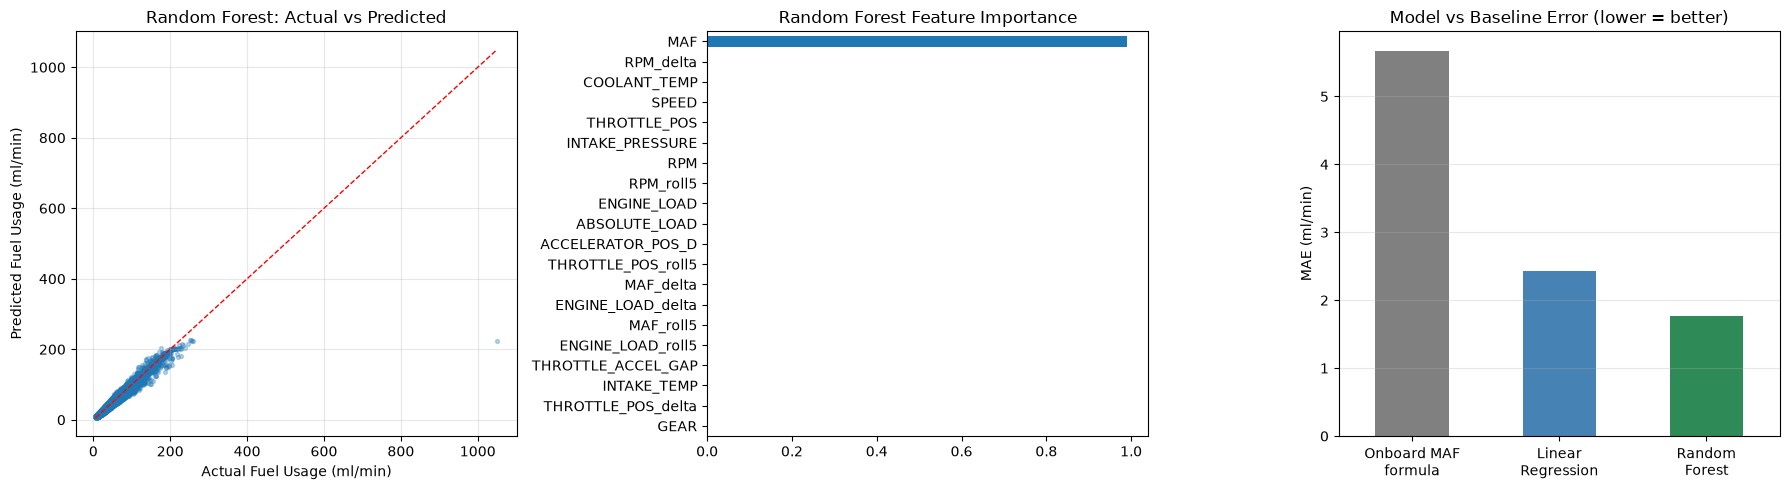

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Actual vs Predicted — Random Forest
axes[0].scatter(y_test, rf_test_pred, alpha=0.3, s=8)
lims = [min(y_test.min(), rf_test_pred.min()), max(y_test.max(), rf_test_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual Fuel Usage (ml/min)")
axes[0].set_ylabel("Predicted Fuel Usage (ml/min)")
axes[0].set_title("Random Forest: Actual vs Predicted")
axes[0].grid(alpha=0.3)

# (b) Feature importance
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", ax=axes[1])
axes[1].set_title("Random Forest Feature Importance")

# (c) MAE comparison — model vs baseline
comparison = pd.Series({
    "Onboard MAF\nformula": baseline_mae,
    "Linear\nRegression": results["Linear Regression_test"]["mae"],
    "Random\nForest": results["Random Forest_test"]["mae"],
})
comparison.plot(kind="bar", ax=axes[2], color=["gray", "steelblue", "seagreen"])
axes[2].set_ylabel("MAE (ml/min)")
axes[2].set_title("Model vs Baseline Error (lower = better)")
axes[2].tick_params(axis="x", rotation=0)
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("fuel_prediction_results.png", dpi=150)
print("Saved plot: fuel_prediction_results.png")
plt.show()